In [1]:
import pandas as pd
import numpy as np
import re

file_path = "C:/Users/rohan/Downloads/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_")

print("✅ Data loaded:", df.shape)
df.head()




✅ Data loaded: (1739, 31)


,id_number,submission_date,age,disability,chapa_races,hispanic_latino,census_races,current_residence_town_city,current_residence_state,current_residence_zip,...,property_unit,property_town_city,property_state,property_zip,match_status,match_type,matched_address,fthb_class,msa,property_restriction
0,150733,2022-02-08,65,0,White/Non-Minority,0.0,White alone,Somerville,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
1,439181,2022-02-08,59,0,Hispanic/Latino,1.0,Unknown,Westford,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
2,697399,2022-02-08,0,0,Black or African American,0.0,Black or African American alone,Malden,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
3,191565,2022-02-08,0,0,White/Non-Minority,0.0,White alone,Haverhill,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
4,226436,2022-02-08,60,0,White/Non-Minority,0.0,White alone,Nashua,NH,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN


In [2]:
df['chapa_races'].dropna().unique()


array(['White/Non-Minority', 'Hispanic/Latino',
       'Black or African American', 'Asian/Pacific Islander',
       'Black or African American; White/Non-Minority',
       'North African or Middle Eastern',
       'Native American/Alaskan Native', 'Unknown',
       'Hispanic/Latino; White/Non-Minority', 'Other', 'White',
       'Native American or Alaskan Native',
       'Middle Eastern or North African', 'Asian', 'Hispanic or Latino',
       'Choose not to answer', 'Asian, White',
       'Asian, Pacific Islander or Native Hawaiian',
       'Black or African American, Hispanic or Latino', 'Missing',
       'Asian, Black or African American, Middle Eastern or North African, White',
       'Middle Eastern or North African, White',
       'Black or African American, Native American or Alaskan Native, White',
       'Hispanic or Latino, White',
       'Asian, Pacific Islander or Native Hawaiian, White',
       'Black or African American, White',
       'Hispanic or Latino, Native American

In [3]:
df['chapa_races'].value_counts(dropna=False)


chapa_races
White                                                                           666
Black or African American                                                       230
White/Non-Minority                                                              209
Hispanic or Latino                                                              149
Asian                                                                           130
Choose not to answer                                                             51
Hispanic/Latino                                                                  46
Asian/Pacific Islander                                                           45
Asian, Pacific Islander or Native Hawaiian                                       44
Middle Eastern or North African                                                  34
Black or African American, Hispanic or Latino                                    26
Unknown                                                         

In [4]:
race_cols = ['chapa_races']
df_race = df[race_cols].copy()
df_race.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   chapa_races  1739 non-null   object
dtypes: object(1)
memory usage: 13.7+ KB


In [5]:
def parse_race_string(race_str):
    if pd.isna(race_str):
        return []

    s = race_str.lower().strip()

    # "white/non-minority" to just white
    s = re.sub(r"\bwhite\s*/\s*non[- ]?minority\b", "white", s)

    # Keep Hispanic/Latino as a single ethnicity
    s = re.sub(r"\bhispanic\s*/\s*latino\b", "hispanic or latino", s)

    # Expand Asian/Pacific Islander to full phrasing
    s = re.sub(r"\basian\s*/\s*pacific islander\b",
               "asian, native hawaiian or pacific islander", s)

    # Normalize Native American/Alaskan 
    s = re.sub(r"\bnative american\s*/\s*alaskan native\b",
               "native american or alaskan native", s)

    # Normalize MENA variants
    s = re.sub(r"\bnorth african or middle eastern\b", 
               "middle eastern or north african", s)

    # Normalize “Black or African American”
    s = re.sub(r"\bblack\s*or\s*african american\b", 
               "black or african american", s)

    # split ONLY on commas/semicolons (NOT on /)
    parts = [p.strip() for p in re.split(r"[;,]", s) if p.strip()]

    return sorted(set(parts))


In [6]:
df['race_list'] = df['chapa_races'].apply(parse_race_string)
df['race_count'] = df['race_list'].apply(len)

def canonical_race(race_terms):
    if not race_terms:
        return ["Other / Prefer not to answer"]

    canonical = []
    for term in race_terms:
        t = term.lower().strip()

        # 1) HIGH-PRIORITY special cases first
        if ("middle eastern" in t) or ("north african" in t):
            canonical.append("Middle Eastern or North African")
            continue  # prevent falling into "african" → Black

        if ("minority" in t and "non" in t) or t == "non-minority" or t == "white/non-minority":
            canonical.append("White")
            continue

        # 2) Standard race buckets
        if "white" in t:
            canonical.append("White")
        elif "asian" in t:
            canonical.append("Asian")
        elif ("pacific" in t) or ("hawaiian" in t):
            canonical.append("Native Hawaiian or Pacific Islander")
        elif "hispanic" in t or "latino" in t:
            canonical.append("Hispanic or Latino")
        elif "native" in t and ("american" in t or "alaskan" in t):
            canonical.append("American Indian or Alaska Native")
        elif "black" in t or "african" in t:
            # Now safe: won't swallow "north african" because MENA already handled
            canonical.append("Black or African American")
        elif any(x in t for x in ["other", "choose", "missing", "unknown", "prefer not to answer"]):
            canonical.append("Other / Prefer not to answer")

    canonical = sorted(set(canonical))
    return canonical if canonical else ["Other / Prefer not to answer"]


df['race_list']   = df['chapa_races'].apply(parse_race_string)
df['race_cleaned'] = df['race_list'].apply(canonical_race)
df['race_type']    = np.where(df['race_cleaned'].apply(len) > 1, "Multiracial", "Single Race")



In [7]:
df.loc[df['chapa_races'].str.contains("Hispanic", case=False, na=False),
       ['chapa_races','race_cleaned','race_type']].head(10)

,chapa_races,race_cleaned,race_type
1,Hispanic/Latino,[Hispanic or Latino],Single Race
11,Hispanic/Latino,[Hispanic or Latino],Single Race
26,Hispanic/Latino,[Hispanic or Latino],Single Race
37,Hispanic/Latino,[Hispanic or Latino],Single Race
56,Hispanic/Latino,[Hispanic or Latino],Single Race
80,Hispanic/Latino,[Hispanic or Latino],Single Race
88,Hispanic/Latino,[Hispanic or Latino],Single Race
93,Hispanic/Latino; White/Non-Minority,"[Hispanic or Latino, White]",Multiracial
125,Hispanic/Latino,[Hispanic or Latino],Single Race
140,Hispanic/Latino; White/Non-Minority,"[Hispanic or Latino, White]",Multiracial


In [8]:
df.loc[df['chapa_races'].str.contains("White/Non-Minority", case=False, na=False),
       ['chapa_races','race_cleaned','race_type']].head(10)

,chapa_races,race_cleaned,race_type
0,White/Non-Minority,[White],Single Race
3,White/Non-Minority,[White],Single Race
4,White/Non-Minority,[White],Single Race
5,White/Non-Minority,[White],Single Race
6,White/Non-Minority,[White],Single Race
7,White/Non-Minority,[White],Single Race
12,Black or African American; White/Non-Minority,"[Black or African American, White]",Multiracial
13,White/Non-Minority,[White],Single Race
14,White/Non-Minority,[White],Single Race
15,White/Non-Minority,[White],Single Race


In [9]:
df.loc[df['chapa_races'].str.contains("Asian/Pacific Islander", case=False, na=False),
       ['chapa_races','race_cleaned','race_type']].head(10)


,chapa_races,race_cleaned,race_type
9,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
10,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
19,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
24,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
25,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
29,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
39,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
41,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
44,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial
62,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial


In [10]:
unique_races = sorted({r for lst in df['race_cleaned'] for r in lst})
for race in unique_races:
    col = f"race_{race.replace(' ', '_').replace('/', '')}"
    df[col] = df['race_cleaned'].apply(lambda L: int(race in L))


In [11]:
df['hispanic_latino_from_race'] = df['race_cleaned'].apply(lambda r: int("Hispanic or Latino" in r))
if 'hispanic_latino' in df.columns:
    df['hispanic_latino_final'] = (
        pd.to_numeric(df['hispanic_latino'], errors='coerce')
          .fillna(df['hispanic_latino_from_race'])
          .astype(int)
    )
else:
    df['hispanic_latino_final'] = df['hispanic_latino_from_race']


In [12]:
df[['chapa_races', 'race_cleaned', 'race_type'] + 
   [col for col in df.columns if col.startswith('race_')]].head(10)

,chapa_races,race_cleaned,race_type,race_list,race_count,race_cleaned,race_type,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Middle_Eastern_or_North_African,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White
0,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
1,Hispanic/Latino,[Hispanic or Latino],Single Race,[hispanic or latino],1,[Hispanic or Latino],Single Race,0,0,0,1,0,0,0,0
2,Black or African American,[Black or African American],Single Race,[black or african american],1,[Black or African American],Single Race,0,0,1,0,0,0,0,0
3,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
4,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
5,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
6,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
7,White/Non-Minority,[White],Single Race,[white],1,[White],Single Race,0,0,0,0,0,0,0,1
8,Black or African American,[Black or African American],Single Race,[black or african american],1,[Black or African American],Single Race,0,0,1,0,0,0,0,0
9,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial,"[asian, native hawaiian or pacific islander]",2,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial,0,1,0,0,0,1,0,0


### Race Data Cleaning & Encoding Summary

- **Objective:** Standardize and encode applicant race information from the `chapa_races` column, aligning with U.S. Census categories and ensuring consistency for equity and demographic analysis.
- **Steps:**
  1. Parsed raw text using an improved `parse_race_string()` that preserved multi-race combinations and normalized ambiguous labels.
  2. Canonically mapped all responses to **eight** standardized categories:  
     *White, Black or African American, Asian, Hispanic or Latino, American Indian or Alaska Native, Native Hawaiian or Pacific Islander, Middle Eastern or North African, Other / Prefer not to answer.*
  3. Created `race_type` to distinguish **Single Race** vs **Multiracial** applicants.
  4. Generated one-hot encoded indicator columns (e.g., `race_White`, `race_Asian`) for modeling or aggregation.
  5. Derived a cleaned `hispanic_latino_final` flag aligned with federal ethnicity definitions.
- **Outcome:** A fully standardized race/ethnicity dataset that supports demographic, equity, and income-based analyses across the 2021–25 applicant pool.



C:\Users\rohan\AppData\Local\Temp\ipykernel_25344\2792441670.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")


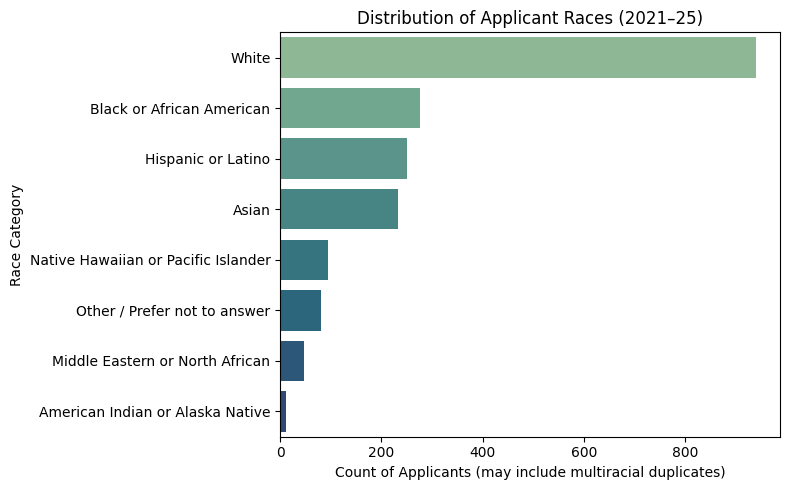

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list
race_flat = [r for sublist in df['race_cleaned'] for r in sublist]
race_series = pd.Series(race_flat)

plt.figure(figsize=(8,5))
sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")
plt.title("Distribution of Applicant Races (2021–25)")
plt.xlabel("Count of Applicants (may include multiracial duplicates)")
plt.ylabel("Race Category")
plt.tight_layout()
plt.show()


C:\Users\rohan\AppData\Local\Temp\ipykernel_25344\2919899147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='race_type', data=df, palette='pastel')


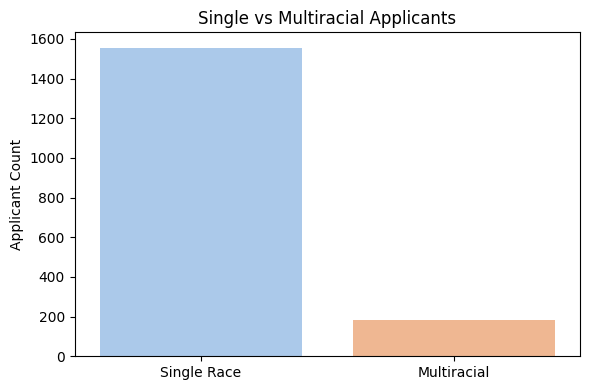

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='race_type', data=df, palette='pastel')
plt.title("Single vs Multiracial Applicants")
plt.xlabel("")
plt.ylabel("Applicant Count")
plt.tight_layout()
plt.show()


In [15]:
df_exploded = df.explode('race_cleaned').reset_index(drop=True)

# Clean and convert household income to numeric
df_exploded['hh_income'] = (
    df_exploded['hh_income']
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

# Clip extreme household incomes for visualization
upper_cap = 500_000
df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

df_exploded[['race_cleaned', 'hh_income_clipped']].head()



,race_cleaned,hh_income_clipped
0,White,37934.0
1,Hispanic or Latino,61000.0
2,Black or African American,31275.0
3,White,20299.0
4,White,41000.0


C:\Users\rohan\AppData\Local\Temp\ipykernel_25344\539791357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


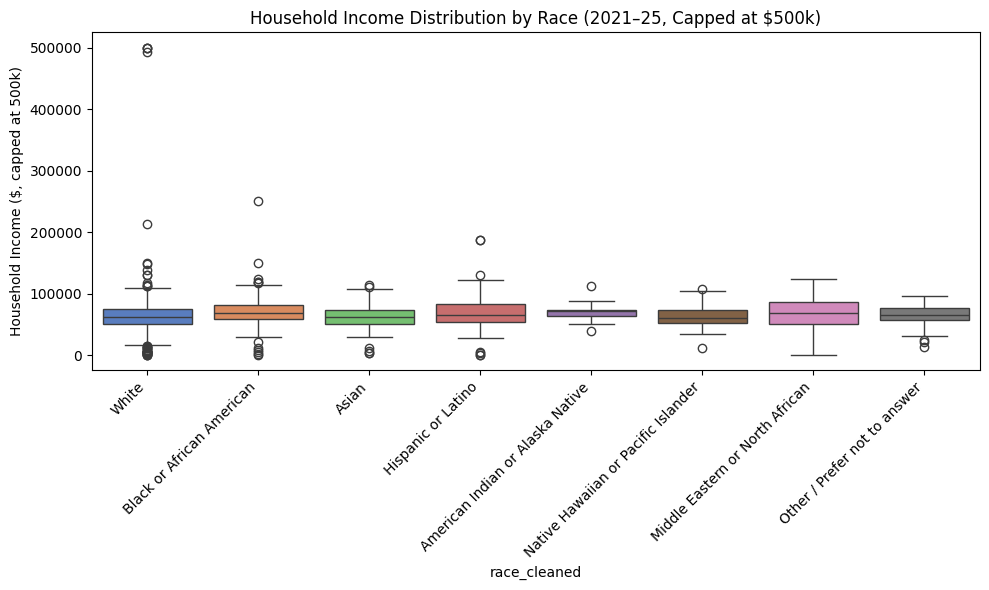

In [16]:
race_order = [
    'White', 'Black or African American', 'Asian', 
    'Hispanic or Latino', 'American Indian or Alaska Native',
    'Native Hawaiian or Pacific Islander', 'Middle Eastern or North African',
    'Other / Prefer not to answer'
]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_exploded,
    x='race_cleaned', y='hh_income_clipped',
    order= race_order,
    palette='muted'
)
plt.title('Household Income Distribution by Race (2021–25, Capped at $500k)')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Household Income ($, capped at 500k)")
plt.tight_layout()
plt.show()


In [17]:
df_exploded.groupby('race_cleaned')['hh_income_clipped']\
    .describe(percentiles=[.25,.5,.75])


,count,mean,std,min,25%,50%,75%,max
race_cleaned,,,,,,,,
American Indian or Alaska Native,11.0,70384.909091,19337.660466,38400.0,63096.00,72000.0,73500.0,113000.0
Asian,232.0,63154.943966,19488.751809,3000.0,50941.25,62000.0,74000.0,114350.0
Black or African American,277.0,70229.833935,22261.003981,70.0,57867.00,68411.0,81250.0,250000.0
Hispanic or Latino,250.0,68173.168000,23537.766335,100.0,54258.25,65000.0,83000.0,187000.0
Middle Eastern or North African,47.0,67889.659574,24634.081572,96.0,50631.00,68000.0,86200.0,124000.0
Native Hawaiian or Pacific Islander,94.0,62515.457447,16602.368776,11000.0,52240.00,61000.0,73675.0,107000.0
Other / Prefer not to answer,79.0,65860.746835,17560.302092,13149.0,57138.00,65871.0,76418.0,96610.0
White,938.0,63813.351812,35143.691669,78.0,51000.00,62000.0,74640.0,500000.0


In [18]:
q = df_exploded.groupby('race_cleaned')['hh_income_clipped']
summary = pd.DataFrame({
    "n": q.size(),
    "median": q.median(),
    "p25": q.quantile(0.25),
    "p75": q.quantile(0.75)
}).loc[race_order]
summary


,n,median,p25,p75
race_cleaned,,,,
White,941,62000.0,51000.00,74640.0
Black or African American,277,68411.0,57867.00,81250.0
Asian,233,62000.0,50941.25,74000.0
Hispanic or Latino,251,65000.0,54258.25,83000.0
American Indian or Alaska Native,11,72000.0,63096.00,73500.0
Native Hawaiian or Pacific Islander,95,61000.0,52240.00,73675.0
Middle Eastern or North African,47,68000.0,50631.00,86200.0
Other / Prefer not to answer,81,65871.0,57138.00,76418.0


### Race Distribution & Income Insights

- **Representation:**  
  White applicants comprise the majority of the dataset, followed by Black or African American, Hispanic or Latino, and Asian applicants.  
  Smaller groups include Native Hawaiian or Pacific Islander, Middle Eastern or North African, American Indian or Alaska Native, and “Other / Prefer not to answer.”

- **Multiracial Breakdown:**  
  Roughly 85–90% of applicants identify with a single race, while about 10–15% report multiple racial backgrounds—consistent with CHAPA’s broader applicant pool.

- **Income Disparities:**  
  When capped at \$500K to reduce outlier distortion, the **median household income** clusters tightly between \$60K–\$70K across most groups.  
  - White and Asian applicants show slightly higher upper quartiles (~\$74K–\$75K).  
  - Hispanic, Black, and Middle Eastern/North African applicants center around \$65K–\$68K, showing minor variation.  
  - Smaller populations (AI/AN and NH/PI) display higher volatility but similar medians.  
  Overall, no extreme race-linked income disparities appear within the capped dataset.

- **Next Steps:**  
  Future visualizations can examine intersections between **race, geography (tract or city)**, and **outcome variables** (e.g., loan approval, homeownership, outreach success) to explore equity dimensions more deeply.
